# 03. Advanced Segmentation using Custom Behavioral Features.

**Process:**
1. Create features
2. Kmeans Clustering 
3. Result Explanation
4. Summary: Summary: Strategic Recommendations and Model Evaluation

In [1]:
%load_ext autoreload
%autoreload 2

## Import library

In [2]:
# Import necessary library

import sys
import os
from pathlib import Path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.cluster_model import ClusterAnalysis
from utils.custom_features_config2 import ALL_FEATURES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### **1. Create customer-level features**

1. Count_TransID: Frequency
2. Sum_SalesAmount: Purchasing Value
3. Mean_SalesAmount: Purchasing Power
4. Pct_TransIDWithVoucherApplied: Voucher Applied Transaction Ratio
5. Mean_DaysBetweenTransaction: Days Between Transaction
6. Count_DistinctMerchant: Merchant Frequency
7. Pct_TransIDByDelivery: Delivery Transaction Ratio
8. Pct_TransIDByApp: App Transaction Ratio

- Number of features: 8
- Using utils.custom_feature_engineering2.CustomFeatureEngineering to extract features to get df (dataframe of transformed features) and df_origin (dataframe of origin features).

In [3]:
raw_features_path= os.path.join(project_root, 'output','customer_features_custom2.csv')
transformed_features_path= os.path.join(project_root,'output','customer_feature_transformed_custom2.csv')

cluster_model = ClusterAnalysis(raw_features_path, transformed_features_path)

### **2. Kmeans Clustering**

Using model ClusterAnalysis to run the comprehend analysis

In [4]:
# Load features from custom_feature_config2
cluster_model._load_features(ALL_FEATURES=ALL_FEATURES)
df, df_origin = cluster_model._load_file(raw_features_path, transformed_features_path)

print(df)
print(df_origin)

Successfully loading file: raw_customer_features: (583618, 8)
Successfully loading file: transformed_customer_features: (583618, 8)
         Count_TransID  Sum_SalesAmount  Mean_SalesAmount  \
userID                                                      
0            -0.638136         0.266328          0.852917   
1            -0.638136        -1.511775         -1.515315   
8            -0.638136         1.319177          2.562210   
16           -0.638136        -0.168030          0.222451   
18           -0.638136        -0.164010          0.228113   
...                ...              ...               ...   
2174065      -0.638136        -1.118850         -1.036659   
2174066      -0.638136        -1.072180         -0.978305   
2174072       1.672809         1.177900          0.402919   
2174075      -0.638136        -0.277235          0.069802   
2174083      -0.638136        -0.727053         -0.536247   

         Pct_TransIDWithVoucherApplied  Mean_DaysBetweenTransaction  \
use

Transformed feature data shape: (583618, 8)
Completed K=2 | Inertia: 2950225 | Silhouette Score: 0.4392
Completed K=3 | Inertia: 2444761 | Silhouette Score: 0.3561
Completed K=4 | Inertia: 1999694 | Silhouette Score: 0.3867
Completed K=5 | Inertia: 1728568 | Silhouette Score: 0.4065
Completed K=6 | Inertia: 1618747 | Silhouette Score: 0.3834
Completed K=7 | Inertia: 1264153 | Silhouette Score: 0.4294
Completed K=8 | Inertia: 1155000 | Silhouette Score: 0.4313
Completed K=9 | Inertia: 1105779 | Silhouette Score: 0.4174
Completed K=10 | Inertia: 1020313 | Silhouette Score: 0.4444
The optimal number of clusters based on Silhouette Score is: 10


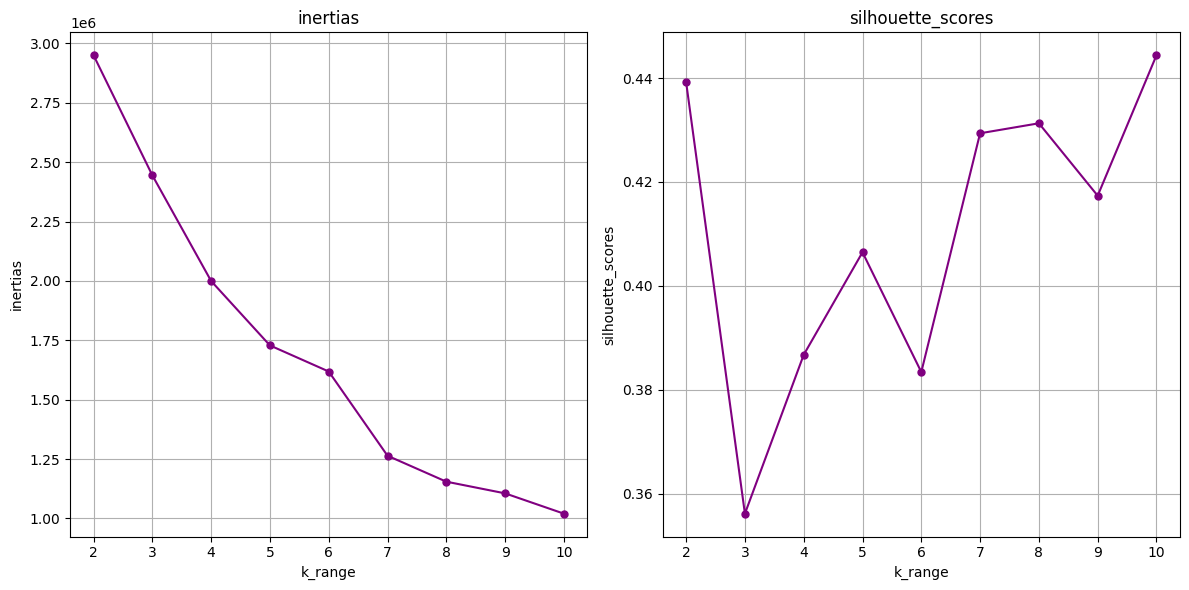

Optimize k by Silhouette Score: k = 10


In [5]:
# Opimal cluster
optimal_clusters = cluster_model._find_optimal_cluster(use_minibatch=True)
cluster_model._plot_optimal_cluster()

Transformed feature data shape: (583618, 8)


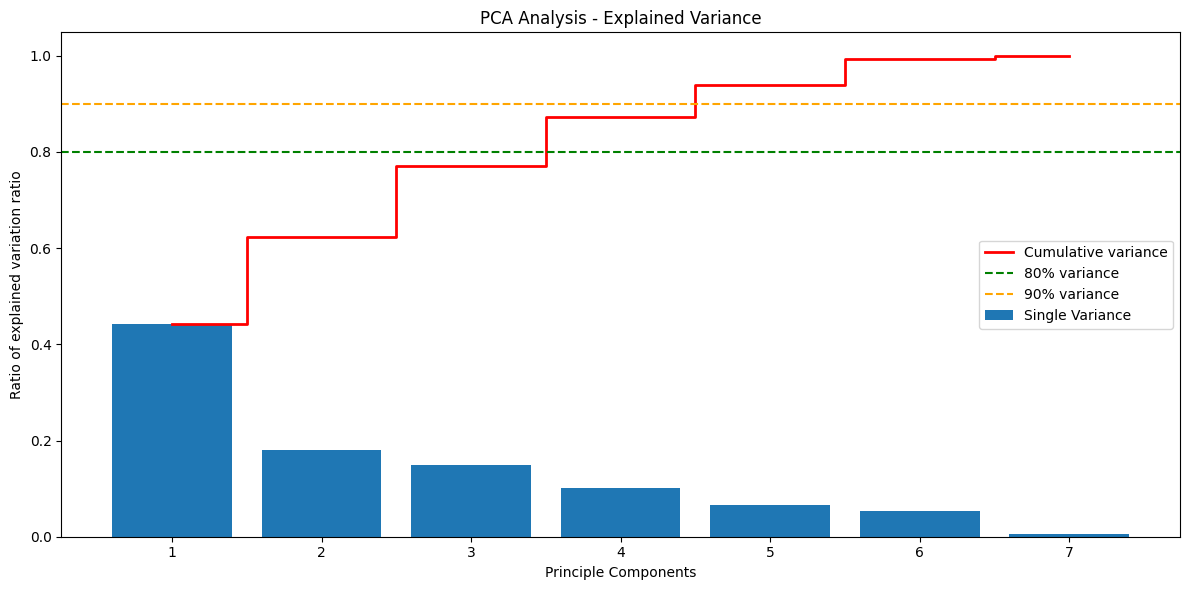

PC1-PC1: 44.31%
PC1-PC2: 62.27%
PC1-PC3: 77.17%
PC1-PC4: 87.31%
PC1-PC5: 93.95%


In [6]:
# PCA Analysis
pca = cluster_model._pca_analysis()
cluster_model._plot_pca_analysis()

Cluster sizes (k=2)
0    415972
1    167646
Name: count, dtype: int64
Cluster sizes (k=3)
0    166896
1    243646
2    173076
Name: count, dtype: int64
Cluster sizes (k=4)
0    242002
1    131197
2     46374
3    164045
Name: count, dtype: int64
Cluster sizes (k=5)
0    241902
1     46240
2    164045
3     59360
4     72071
Name: count, dtype: int64
                      PC1       PC2       PC3       PC4       PC5
clusters_by_k_5                                                  
0               -1.437527 -0.393917  0.101163  0.553093  0.060417
1                3.296628  0.461723  2.434762  0.153626  0.654109
2               -0.578943  1.168503 -0.160757 -0.721556  0.024380
3                2.871604 -1.486016 -0.904952 -0.081226  0.147357
4                1.662512 -0.409842 -0.790409 -0.245712 -0.799317


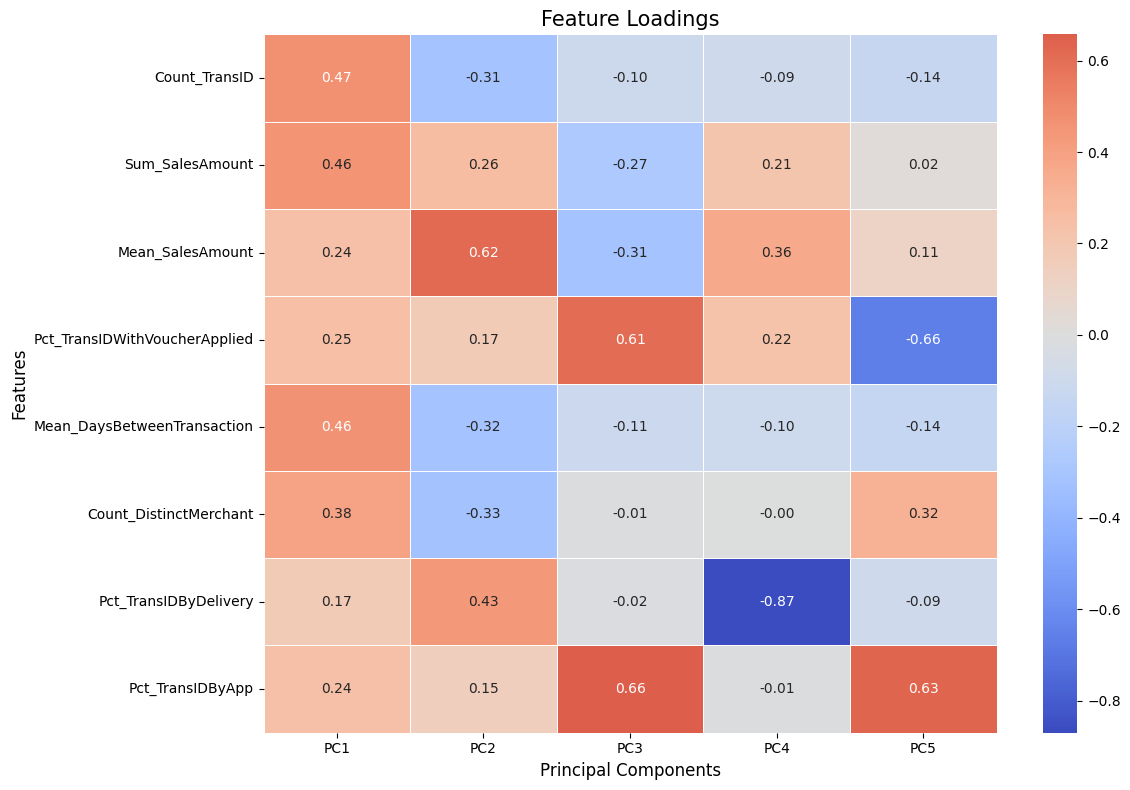

In [7]:
# Apply Kmeans
cluster_results = cluster_model._apply_kmeans(k_values=[2,3,4,5])
cluster_model._feature_loading()

##### **Highlights: Principal Component Analysis (PCA) Interpretation**

1. **PC1 (Engagement & Scale)**: This component shows strong positive loadings across frequency and volume metrics. It is primarily driven by **Transaction Count** (0.47), **Total Sales Amount** (0.46), **Average Days Between Transactions** (0.46), and **Merchant Diversity** (0.38).
    * **Significance:** A higher PC1 score represents "Power Users" with a long customer lifecycle—those who shop frequently, visit multiple locations, and contribute high total revenue.

2. **PC2 (Order Value & Delivery Preference)**: This axis shows a strong positive correlation with **Mean Sales Amount** (0.62) and **Delivery Percentage** (0.43), while being negatively correlated with transaction count (-0.31).
    * **Significance:** High PC2 scores identify "Big Spenders" who may not visit often but place high-value orders, typically through delivery channels.

3. **PC3 (Tech-Savviness & Promotion Engagement)**: This component is heavily dominated by **App Usage Rate** (0.66) and **Voucher Redemption Rate** (0.61).
    * **Significance:** This is the "Digital Engagement" axis. High scores indicate tech-savvy customers who primarily order via the app and are highly responsive to promotional discounts.

4. **PC4 (In-Store vs. Delivery Orientation)**: This axis is defined by a very deep negative loading on **Delivery Percentage** (-0.87).
    * **Significance:** This is a channel-preference toggle. Lower (negative) scores indicate a heavy reliance on Delivery, while higher (positive) scores indicate a preference for "Brick-and-Mortar" experiences (Dine-in or Take-away).

5. **PC5 (Convenience-Oriented App Users)**: This component shows positive loadings for App usage (0.63) but negative loadings for voucher application (-0.66).
    * **Significance:** Represents "Convenience Seekers"—customers who use the digital app for its streamlined experience and efficiency rather than for seeking discounts.

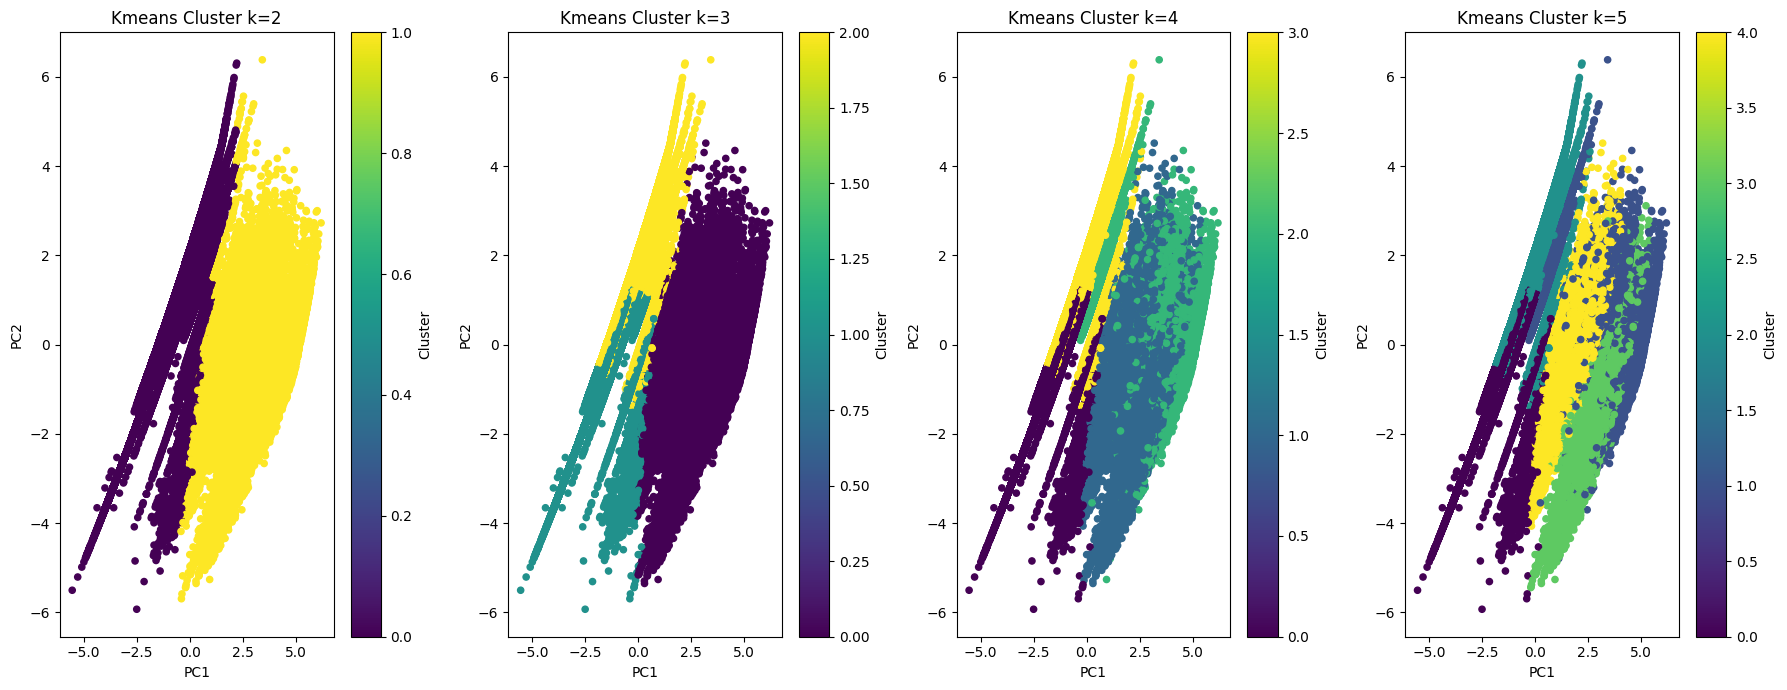

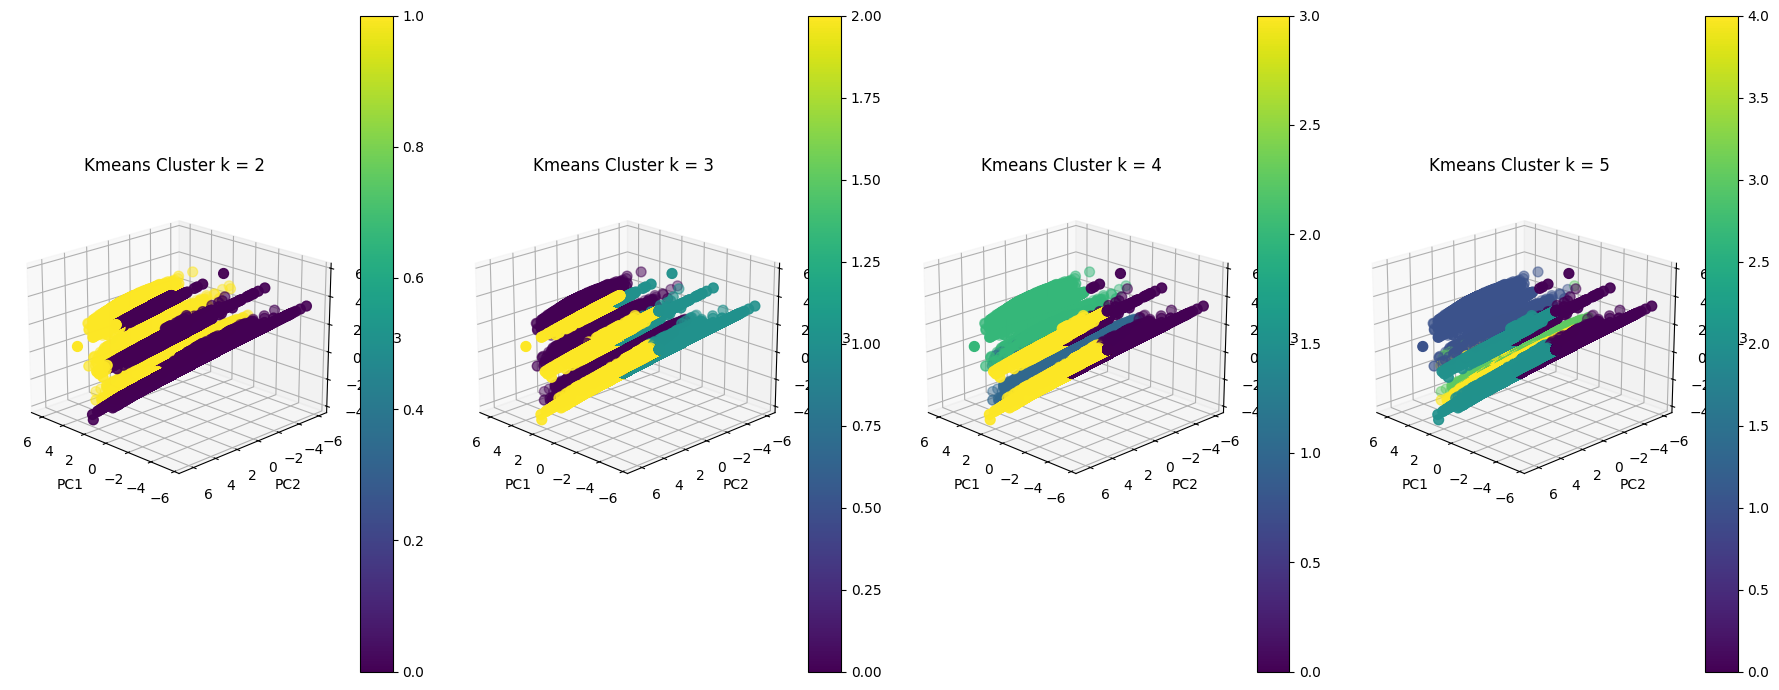

In [8]:
# Visualize 2D & 3D
cluster_model._plot_cluster_2d(k_values=[2,3,4,5])
cluster_model._plot_cluster_3d(k_values=[2,3,4,5])

In [9]:
# Visualization Cohort Frame
cluster_model._display_cohort_table(k_values = [2,3,4,5])


=== CLUSTER ANALYSIS K=2 ===
Cluster 0: 415972 users (71.27%)
Cluster 1: 167646 users (28.73%)


,Count_TransID,Sum_SalesAmount,Mean_SalesAmount,Pct_TransIDWithVoucherApplied,Mean_DaysBetweenTransaction,Count_DistinctMerchant,Pct_TransIDByDelivery,Pct_TransIDByApp
clusters_by_k_2,,,,,,,,
0,1.010000,293943.260000,293951.560000,0.060000,0.090000,1.000000,0.400000,0.060000
1,3.750000,1097213.900000,319064.390000,0.110000,94.630000,1.570000,0.520000,0.120000



=== CLUSTER ANALYSIS K=3 ===
Cluster 0: 166896 users (28.60%)
Cluster 1: 243646 users (41.75%)
Cluster 2: 173076 users (29.66%)


,Count_TransID,Sum_SalesAmount,Mean_SalesAmount,Pct_TransIDWithVoucherApplied,Mean_DaysBetweenTransaction,Count_DistinctMerchant,Pct_TransIDByDelivery,Pct_TransIDByApp,clusters_by_k_2
clusters_by_k_3,,,,,,,,,
0,3.760000,1099511.940000,318592.380000,0.110000,94.870000,1.570000,0.520000,0.120000,1.000000
1,1.020000,229715.920000,227701.060000,0.030000,0.290000,1.000000,0.010000,0.020000,0.000000
2,1.000000,385623.530000,387779.020000,0.110000,0.000000,1.000000,0.950000,0.120000,0.000000



=== CLUSTER ANALYSIS K=4 ===
Cluster 0: 242002 users (41.47%)
Cluster 1: 131197 users (22.48%)
Cluster 2: 46374 users (7.95%)
Cluster 3: 164045 users (28.11%)


,Count_TransID,Sum_SalesAmount,Mean_SalesAmount,Pct_TransIDWithVoucherApplied,Mean_DaysBetweenTransaction,Count_DistinctMerchant,Pct_TransIDByDelivery,Pct_TransIDByApp,clusters_by_k_2,clusters_by_k_3
clusters_by_k_4,,,,,,,,,,
0,1.010000,229805.890000,227977.250000,0.030000,0.180000,1.000000,0.010000,0.010000,0.000000,1.000000
1,3.510000,1002764.780000,310208.160000,0.060000,97.050000,1.510000,0.490000,0.000000,1.000000,0.000000
2,3.850000,1201290.590000,349088.130000,0.470000,67.430000,1.620000,0.640000,0.660000,0.780000,0.410000
3,1.000000,386075.900000,388354.070000,0.060000,0.000000,1.000000,0.960000,0.070000,0.000000,2.000000



=== CLUSTER ANALYSIS K=5 ===
Cluster 0: 241902 users (41.45%)
Cluster 1: 46240 users (7.92%)
Cluster 2: 164045 users (28.11%)
Cluster 3: 59360 users (10.17%)
Cluster 4: 72071 users (12.35%)


,Count_TransID,Sum_SalesAmount,Mean_SalesAmount,Pct_TransIDWithVoucherApplied,Mean_DaysBetweenTransaction,Count_DistinctMerchant,Pct_TransIDByDelivery,Pct_TransIDByApp,clusters_by_k_2,clusters_by_k_3,clusters_by_k_4
clusters_by_k_5,,,,,,,,,,,
0,1.010000,229789.840000,228019.630000,0.030000,0.160000,1.000000,0.010000,0.010000,0.000000,1.000000,0.000000
1,3.820000,1196787.950000,349310.160000,0.470000,67.530000,1.620000,0.640000,0.670000,0.780000,0.420000,2.000000
2,1.000000,386075.900000,388354.070000,0.060000,0.000000,1.000000,0.960000,0.070000,0.000000,2.000000,3.000000
3,4.170000,1142128.200000,303088.480000,0.040000,111.880000,2.130000,0.420000,0.000000,1.000000,0.000000,1.000000
4,2.980000,890219.930000,315745.670000,0.070000,84.650000,1.000000,0.540000,0.000000,1.000000,0.010000,1.000000


In [10]:
df_cluster_4 = df_origin.drop(columns=['clusters_by_k_2','clusters_by_k_3','clusters_by_k_5'])
df_cluster_4

,Count_TransID,Sum_SalesAmount,Mean_SalesAmount,Pct_TransIDWithVoucherApplied,Mean_DaysBetweenTransaction,Count_DistinctMerchant,Pct_TransIDByDelivery,Pct_TransIDByApp,clusters_by_k_4
userID,,,,,,,,,
0,1.0,411663.0,4.116630e+05,0.0,0.0,1.0,1.000000,0.000000,3
1,1.0,105503.0,1.055030e+05,0.0,0.0,1.0,1.000000,0.000000,3
8,1.0,1098496.0,1.098496e+06,0.0,0.0,1.0,1.000000,0.000000,3
16,1.0,286558.0,2.865580e+05,0.0,0.0,1.0,1.000000,0.000000,3
18,1.0,287492.0,2.874920e+05,0.0,0.0,1.0,0.000000,0.000000,0
...,...,...,...,...,...,...,...,...,...
2174065,1.0,138943.0,1.389430e+05,0.0,0.0,1.0,0.000000,0.000000,0
2174066,1.0,143685.0,1.436850e+05,0.0,0.0,1.0,0.000000,0.000000,0
2174072,3.0,953618.0,3.178727e+05,0.0,41.0,2.0,0.333333,0.333333,2


### **3. Result Explanation: Customer Persona Analysis**

Based on the Centroid scores, the four distinct customer clusters are identified as follows:

#### **Cluster 0: Casual Walk-in Customers**
* **Characteristics:** Lowest **PC1** score (-1.44), positive **PC4** score (0.55).
* **Analysis:** A deeply negative PC1 indicates very low purchase frequency, minimal total spend, and lack of brand loyalty. The positive PC4 suggests a preference for physical visits over delivery services.
* **Persona:** These are "passersby" who visit the store once or twice and do not return. They are not a core value-driving segment for the business.

#### **Cluster 1: Traditional Loyalists**
* **Characteristics:** Very high **PC1** (2.21), negative **PC2** (-0.89), and negative **PC3** (-0.84).
* **Analysis:** A strongly positive PC1 reflects high frequency and high lifetime value. However, the negative PC2 indicates a small average basket size (small orders). The deeply negative PC3 suggests they are "tech-averse," rarely using the mobile app or vouchers.
* **Persona:** Neighborhood regulars who prefer in-person interactions and manual payments rather than ordering through digital platforms.

#### **Cluster 2: Tech-savviers**
* **Characteristics:** Extremely high **PC1** (3.30) and an outstanding **PC3** (2.43).
* **Analysis:** This is the most potential customer segment. They exhibit high spending and frequency (PC1) while fully leveraging the mobile app and promotional campaigns (PC3).
* **Persona:** "Die-hard fans" of the brand on digital platforms. They generate the highest revenue and engage most actively with App-based marketing. Retaining this group is critical for business growth.

#### **Cluster 3: High-Value Delivery Spenders**
* **Characteristics:** Highest **PC2** (1.17), deeply negative **PC4** (-0.72), and negative **PC1** (-0.58).
* **Analysis:** While their visit frequency is low (negative PC1), their average transaction value is exceptionally high (positive PC2). The deeply negative PC4 confirms they are almost entirely dependent on delivery channels.
* **Persona:** These are likely "Group Orderers" (e.g., department heads or family representatives) who place large bulk orders via delivery apps. They rarely visit the physical storefront.

In [11]:
df_cluster_4 = df_cluster_4.reset_index()

In [12]:
df_fact = pd.read_csv(f'{os.path.join(project_root,'output','fact_merge.csv')}', delimiter=',',encoding='utf-8-sig')
df_cluster_4_merge = pd.merge(df_cluster_4[['userID','clusters_by_k_4']],df_fact, on='userID', how='right')

In [13]:
df_c0 = df_cluster_4_merge[df_cluster_4_merge['clusters_by_k_4'] == 0]
df_c1 = df_cluster_4_merge[df_cluster_4_merge['clusters_by_k_4'] == 1]
df_c2 = df_cluster_4_merge[df_cluster_4_merge['clusters_by_k_4'] == 2]
df_c3 = df_cluster_4_merge[df_cluster_4_merge['clusters_by_k_4'] == 3]

In [ ]:
# Cluster 0: Casual Walk-in Customers
for col in ['Channel','OrderFrom','Gender','VoucherStatus','merchantName','Province']:
    print(df_c0[col].value_counts())
    print('-'*20)

Channel
Take Away    237593
Dine In        4380
Delivery       3309
Name: count, dtype: int64
--------------------
OrderFrom
STORE          200853
WEBSITE         29964
CALL CENTER     11670
APP              2795
Name: count, dtype: int64
--------------------
Gender
Unknown    214777
Male        19007
Female      11498
Name: count, dtype: int64
--------------------
VoucherStatus
No     238792
Yes      6490
Name: count, dtype: int64
--------------------
merchantName
Pizza4P             156389
KFC                  63784
Highlands Coffee     25109
Name: count, dtype: int64
--------------------
Province
Hanoi                 70357
Southern Provinces    70170
Nothern Provinces     54035
Ho Chi Minh City      50720
Name: count, dtype: int64
--------------------


In [ ]:
# Cluster 1: Traditional Loyalists
for col in ['Channel','OrderFrom','Gender','VoucherStatus','merchantName','Province']:
    print(df_c1[col].value_counts())
    print('-'*20)

Channel
Delivery     232801
Take Away    216630
Dine In       10663
Name: count, dtype: int64
--------------------
OrderFrom
STORE          247493
CALL CENTER    111593
WEBSITE        100850
APP               158
Name: count, dtype: int64
--------------------
Gender
Unknown    287380
Male       103361
Female      69353
Name: count, dtype: int64
--------------------
VoucherStatus
No     436943
Yes     23151
Name: count, dtype: int64
--------------------
merchantName
Pizza4P             255508
Highlands Coffee    124100
KFC                  80486
Name: count, dtype: int64
--------------------
Province
Hanoi                 146012
Ho Chi Minh City      128772
Southern Provinces    117658
Nothern Provinces      67652
Name: count, dtype: int64
--------------------


In [ ]:
# Cluster 2: Digital VIPs & "Deal Hunters
for col in ['Channel','OrderFrom','Gender','VoucherStatus','merchantName','Province']:
    print(df_c2[col].value_counts())
    print('-'*20)

Channel
Delivery     107068
Take Away     63791
Dine In        7537
Name: count, dtype: int64
--------------------
OrderFrom
APP            95055
STORE          34908
WEBSITE        29384
CALL CENTER    19049
Name: count, dtype: int64
--------------------
Gender
Male       123398
Female      44904
Unknown     10094
Name: count, dtype: int64
--------------------
VoucherStatus
No     122355
Yes     56041
Name: count, dtype: int64
--------------------
merchantName
Highlands Coffee    115647
Pizza4P              52048
KFC                  10701
Name: count, dtype: int64
--------------------
Province
Ho Chi Minh City      63307
Hanoi                 58342
Southern Provinces    38815
Nothern Provinces     17932
Name: count, dtype: int64
--------------------


In [ ]:
# Cluster 3: High-Value Delivery Spenders
for col in ['Channel','OrderFrom','Gender','VoucherStatus','merchantName','Province']:
    print(df_c3[col].value_counts())
    print('-'*20)

Channel
Delivery     157740
Take Away      6136
Dine In         927
Name: count, dtype: int64
--------------------
OrderFrom
WEBSITE        63142
CALL CENTER    46099
STORE          44630
APP            10932
Name: count, dtype: int64
--------------------
Gender
Unknown    121789
Male        26384
Female      16630
Name: count, dtype: int64
--------------------
VoucherStatus
No     154362
Yes     10441
Name: count, dtype: int64
--------------------
merchantName
Pizza4P             88299
Highlands Coffee    59350
KFC                 17154
Name: count, dtype: int64
--------------------
Province
Ho Chi Minh City      61568
Hanoi                 46989
Southern Provinces    30136
Nothern Provinces     26110
Name: count, dtype: int64
--------------------


### **4. Summary: Strategic Recommendations and Model Evaluation**

Based on the four identified clusters, the following marketing recommendations and strategic approaches are proposed:

#### **Strategic Recommendations**

**Cluster 0: Casual Walk-in Customers**
*Description: High take-away rate, low retention, and moderate average order value (AOV).*
* **Objective - Approach:**
    * **Drive Repeat Transactions:** Encourage return visits through in-store promotions such as "Keep your receipt for a 2-hour return discount" or physical stamp cards (e.g., "Discount/Free gift on your 2nd visit").
    * **Boost Initial Order Value:** Introduce "Newcomer Combo" packages to maximize revenue from the very first transaction.

**Cluster 1: Traditional Loyalists**
*Description: The 2nd highest contributor in volume and value. High Dine-in preference; prefers ordering via Website or Call Center.*
* **Objective - Approach:**
    * **Increase Basket Size:** Design table-service combos for groups of 2-4 (e.g., "Weekend Tea & Cake Sets"). Since this group has the highest Dine-in rate and often visits with family/friends, bundles will effectively increase average spend.
    * **Enhance Payment Experience:** Implement "Order & Pay at Table" via QR codes. Rather than forcing app downloads, QR codes allow seamless re-ordering of snacks/drinks without interrupting their social experience, serving as a natural digital bridge.
    * **Elevate In-store Experience:** Launch physical loyalty cards or phone-number-based recognition at the counter. Offer personalized perks such as free side dishes or specialized in-store services (e.g., birthday party hosting).

**Cluster 2: Tech-Savviers**
*Description: Highest contributor in volume and value. Highest delivery rate and highest coupon redemption rate.*
* **Objective - Approach:**
    * **Optimize Revenue:** Use conditional promotions (e.g., "$5 off for orders over $20") to push spending beyond their typical threshold.
    * **Enhance Customer Experience:** Establish a VIP Tier program (Gold/Diamond) with exclusive App-only privileges. Integrate mini-games to earn vouchers to maintain high engagement levels.
    * **Digital Interaction:** Organize gamification campaigns to reward loyalty and strengthen brand affinity.

**Cluster 3: High-Value Delivery Spenders**
*Description: Focused on high-value transactions via delivery channels.*
* **Objective - Approach:**
    * **Target Corporate/Bulk Orders:** Create "Office Combos" (serving 5-10 people) with slight discounts, optimized specifically for delivery platforms.
    * **Retention via Timing:** Utilize App Push Notifications or Zalo ZNS with "Free Shipping for Large Orders" during peak hours (e.g., 2 PM - 3 PM) to capture the "office tea break" culture.

---

#### **Model Challenges**

While K-means produced qualitatively meaningful segments, the model's reliability remains a significant concern due to the divergence between the algorithm's assumptions and the actual data distribution.

**1. Technical Limitations**
* **Cluster Overlap:** 2D and 3D visualizations reveal a "flat scatter" pattern rather than distinct spherical clusters. This indicates significant boundary overlap, despite input features having low correlation.
* **Suboptimal K-value:** Silhouette analysis peaked at k=10. Selecting k=4 for business interpretability significantly reduced intra-cluster cohesion and inter-cluster separation.
* **Information Loss:** The 3D PCA projection explains only 77% of total variance. The 23% loss likely contains critical information needed to separate the currently overlapping data points.

**2. Root Cause Analysis**
* **Data Distribution Issues:** A disproportionately high volume of one-time transactions creates a high-density "noise zone" at the center of the vector space. As a distance-based algorithm, K-means is easily biased by this noise, forcing unrelated points into mismatched clusters.
* **Feature Insufficiency:** Current features rely heavily on raw transaction metrics. There is a lack of latent behavioral indicators or interaction features that could provide stronger "information axes" for clearer classification.

#### **Proposed Improvements**
The current K-means model should be viewed as exploratory. For production-grade implementation, it is recommended to transition toward density-based algorithms (**DBSCAN**) or probabilistic models (**GMM**) to handle noise and overlapping clusters more effectively.